## Setup

In [11]:
# main
import numpy as np
import pandas as pd
from statsmodels.tsa.stattools import lagmat

# plotting
import seaborn as sns
import matplotlib.pyplot as plt
import networkx as nx
sns.set(rc={'figure.figsize': (9, 9)})

In [252]:
# assign colours to edges depending on positive or negative correlation
def assign_colour(correlation):
    if correlation <= 0:
        return "#ffa09b"  # red
    else:
        return "#9eccb7"  # green

# assign edge thickness depending on magnitude of correlation
def assign_thickness(correlation, benchmark_thickness=2, scaling_factor=3):
    return benchmark_thickness * abs(correlation)**scaling_factor


def assign_node_size(degree, scaling_factor=50):
    return degree * scaling_factor

# define a function that "rounds" a number to 0 if it is lower than threshold, and to 1 if it is higher (or equal).
def truncate(f, threshold=0.92): 
    if (abs(f) < threshold):
        return 0
    else:
        return 1.0

In [114]:
# 'winner takes all' method - set minium correlation threshold to remove some edges from the diagram
def plot_minimum_spanning_tree(corr, threshold=0.4, node_size=200, width=1.2,
                               node_color="#e1575c",color_legend=None,
                               title=None, title_text_size=18):
    font_dict = {'fontsize': title_text_size}

    #convert matrix to list of edges and rename the columns
    edges = corr.stack().reset_index()
    edges.columns = ['asset_1','asset_2','correlation']

    #remove self correlations
    edges = edges.loc[edges['asset_1'] != edges['asset_2']].copy()

    # create a new graph from edge list
    Gx = nx.from_pandas_edgelist(edges, 'asset_1', 'asset_2', edge_attr=['correlation'])

    # list to store edges to remove
    remove = []

    # loop through edges in Gx and find correlations which are below the threshold
    for asset_1, asset_2 in Gx.edges():
        corr_i = Gx[asset_1][asset_2]['correlation']
        if abs(corr_i) < threshold:
            remove.append((asset_1, asset_2))

    # remove edges contained in the remove list
    Gx.remove_edges_from(remove)

    edge_colours = []
    edge_width = []
    for key, value in nx.get_edge_attributes(Gx, 'correlation').items():
        edge_colours.append(assign_colour(value))
        edge_width.append(assign_thickness(value))

    # assign node size depending on number of connections (degree)
    node_size = []
    for key, value in dict(Gx.degree).items():
        node_size.append(assign_node_size(value))

    # create minimum spanning tree layout from Gx (after small correlations have been removed)
    mst = nx.minimum_spanning_tree(Gx)

    edge_colours = []

    #assign edge colours
    for key, value in nx.get_edge_attributes(mst, 'correlation').items():
        edge_colours.append(assign_colour(value))
    
    #  Using a figure to setup the legend
    has_legend = type(color_legend)!=type(None)
    if has_legend:
        f = plt.figure(1)
        ax = f.add_subplot(1,1,1)
        for label, color in color_legend.items():
            ax.plot([0],[0],
                    color=color,
                    label=label)
    
    #draw minimum spanning tree. Set node size and width to constant
    custom_color = [node_colors[node] for node in Gx] if type(node_color)!=str else node_color
    nx.draw(mst, with_labels=True, pos=nx.fruchterman_reingold_layout(mst),
            node_size=node_size, node_color=custom_color,
            edge_color = edge_colours, width = width)

    #set title
    plt.title(title, fontdict=font_dict)
    if has_legend:
        plt.legend(loc='upper right')
        f.tight_layout()

## Overview

In [170]:
# Partition groups
autoregressive = ['real_y_ms_yoy']
financial_conditions = ['consumer_AMD', 'consumer_USD', 
                        'mortgage_AMD', 'mortgage_USD', 
                        'business_AMD', 'business_USD']
policy_conditions = ['tbill', 'gbond','policy_rate']
intermediation = ['loan_to_deposit', 'spread(loan-deposit)', 'spread(loan-tbill)']
housing = ['mortgage_stock_yoy', 'rep_yoy', 'rep_deviation']
leverage = ['credit_to_gdp_gap', 'household_credit_stock_yoy', 'business_credit_stock_yoy', 
            'npl', 'assets_equity']
external_sector = ['exchange_rate', 'net_tr_yoy', 'rus_y_yoy', 'copper_yoy_lag2', 'copper_yoy']

# main groups
dict_groups = {
    'autoregressive': autoregressive, 
    'financial_conditions': financial_conditions, 
    'policy_conditions':policy_conditions,
    'intermediation': intermediation, 
    'housing': housing,
    'leverage': leverage,
    'external_sector':external_sector
}
target_group = {
    'real_y_ms':['real_y_ms']
}

# assigning a color for each group
color_mapping = {'autoregressive':'#1f77b4', 'financial_conditions':'#ff7f0e', 
                 'policy_conditions':'#2ca02c', 'intermediation':'#d62728',
                'housing':'#9467bd', 'leverage':'#8c564b', 'external_sector':'#e377c2',
                 'real_y_ms':'purple'
                }
node_colors = {value: color_mapping[key] for key, values in (dict_groups|target_group).items() for value in values}

In [171]:
data = pd.read_excel('../data/gar_V2.xlsm', "Data", index_col=0)
partition_df = pd.read_excel('../data/gar_V2.xlsm', "Output_partitions", index_col=0)

In [172]:
display(data.head(2))
display(partition_df.head(2))

,real_y_ms,real_y_ms_yoy,consumer_AMD,consumer_USD,mortgage_AMD,mortgage_USD,business_AMD,business_USD,tbill,gbond,...,household_credit_stock_yoy,business_credit_stock_yoy,npl,loan_to_deposit,assets_equity,exchange_rate,net_tr_yoy,rus_y_yoy,copper_yoy,copper_yoy_lag2
date,,,,,,,,,,,,,,,,,,,,,
2003-03-31,2.227874e+06,0.135015,0.238012,0.259848,NaN,NaN,0.194707,0.196707,0.136542,NaN,...,0.106819,0.162437,0.105966,0.582199,6.734091,0.025316,0.173863,0.056282,0.068447,NaN
2003-06-30,2.301517e+06,0.149099,0.243216,0.254005,NaN,NaN,0.204953,0.171420,0.134110,NaN,...,0.234422,0.116824,0.086180,0.568404,6.949840,0.009908,0.255078,0.065036,0.018353,NaN


,autoregressive,financial_conditions,policy_conditions,intermediation,housing,leverage,external_sector,real_y_ms_hz_4
date,,,,,,,,
2003-03-31,1.184524,2.407731,-3.230271,-1.603592,2.334607,-0.664713,0.049095,13.508023
2003-06-30,1.393630,2.304800,-3.183327,-1.776733,2.439979,-0.572048,0.321330,12.249749


In [173]:
corr = data.corr()
display(corr.iloc[1])

real_y_ms                    -0.421804
real_y_ms_yoy                 1.000000
consumer_AMD                  0.258230
consumer_USD                  0.410850
mortgage_AMD                  0.057385
mortgage_USD                 -0.276860
business_AMD                  0.448805
business_USD                  0.450091
tbill                        -0.229370
gbond                        -0.434178
policy_rate                  -0.111784
spread(loan-deposit)          0.548576
spread(loan-tbill)            0.535335
mortgage_stock_yoy            0.688408
rep_yoy                       0.767362
rep_deviation                -0.411773
credit_to_gdp_gap            -0.228133
household_credit_stock_yoy    0.653014
business_credit_stock_yoy     0.119862
npl                          -0.408293
loan_to_deposit              -0.542391
assets_equity                -0.211458
exchange_rate                -0.686105
net_tr_yoy                    0.374274
rus_y_yoy                     0.891932
copper_yoy               

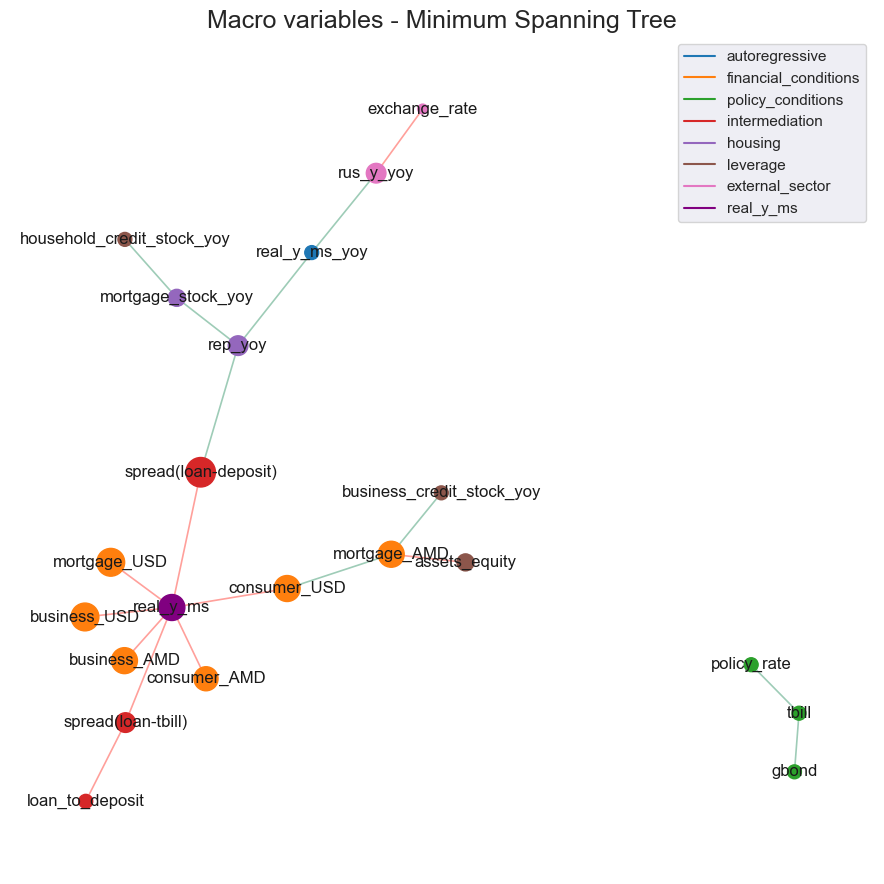

In [169]:
drop_cols = ['copper_yoy', 'rep_deviation', 'credit_to_gdp_gap', 
             'copper_yoy_lag2', 'npl', 'net_tr_yoy']
working_corr = corr.drop(index=drop_cols, columns=drop_cols).copy()
plot_minimum_spanning_tree(working_corr, title="Macro variables - Minimum Spanning Tree",
                           threshold=0.7, node_size=200, color_legend=color_mapping,
                           node_color=node_colors, width = 1.2)
plt.show()

In [176]:
partition_corr = partition_df.corr()
display(partition_corr.iloc[-1])

autoregressive          0.390165
financial_conditions    0.440171
policy_conditions      -0.500814
intermediation         -0.566620
housing                 0.388971
leverage               -0.127658
external_sector         0.528472
real_y_ms_hz_4          1.000000
Name: real_y_ms_hz_4, dtype: float64

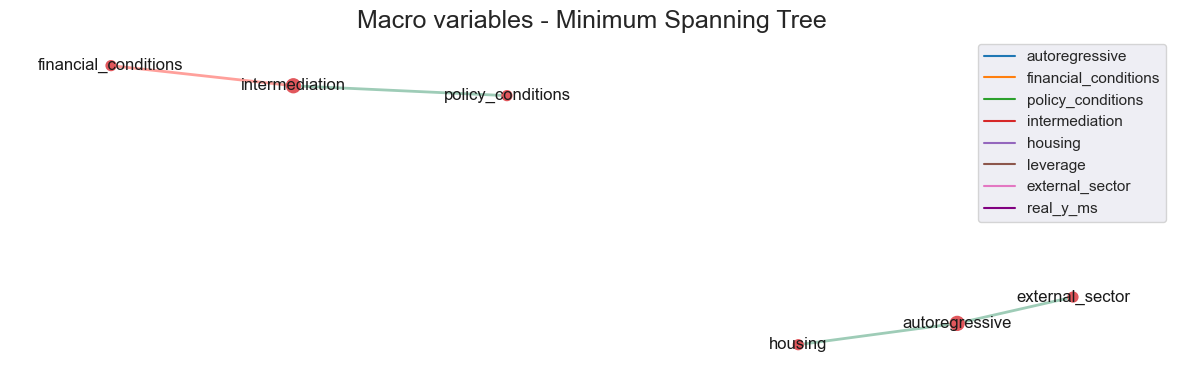

In [225]:
sns.set(rc={'figure.figsize': (12, 4)})
drop_cols = ['leverage', 'real_y_ms_hz_4']
working_corr = partition_corr.drop(index=drop_cols, columns=drop_cols).copy()
plot_minimum_spanning_tree(working_corr, title="Macro variables - Minimum Spanning Tree",
                           threshold=0.7, node_size=1000, color_legend=color_mapping,
                           width = 2)
plt.show()

## Correlation analysis

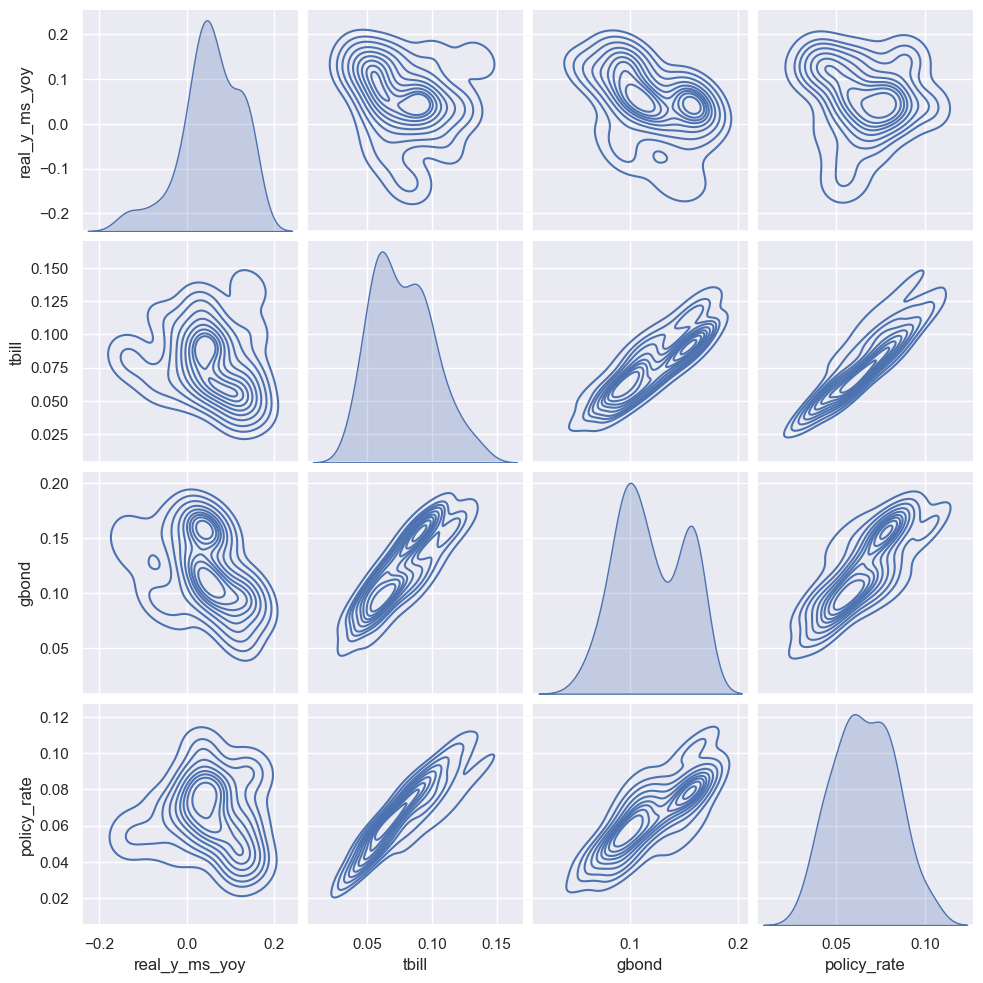

In [227]:
data_subset6 = pd.concat([data['real_y_ms_yoy'], data.iloc[:,8:11]], axis=1)
sns.pairplot(data_subset6, kind="kde")
plt.show()

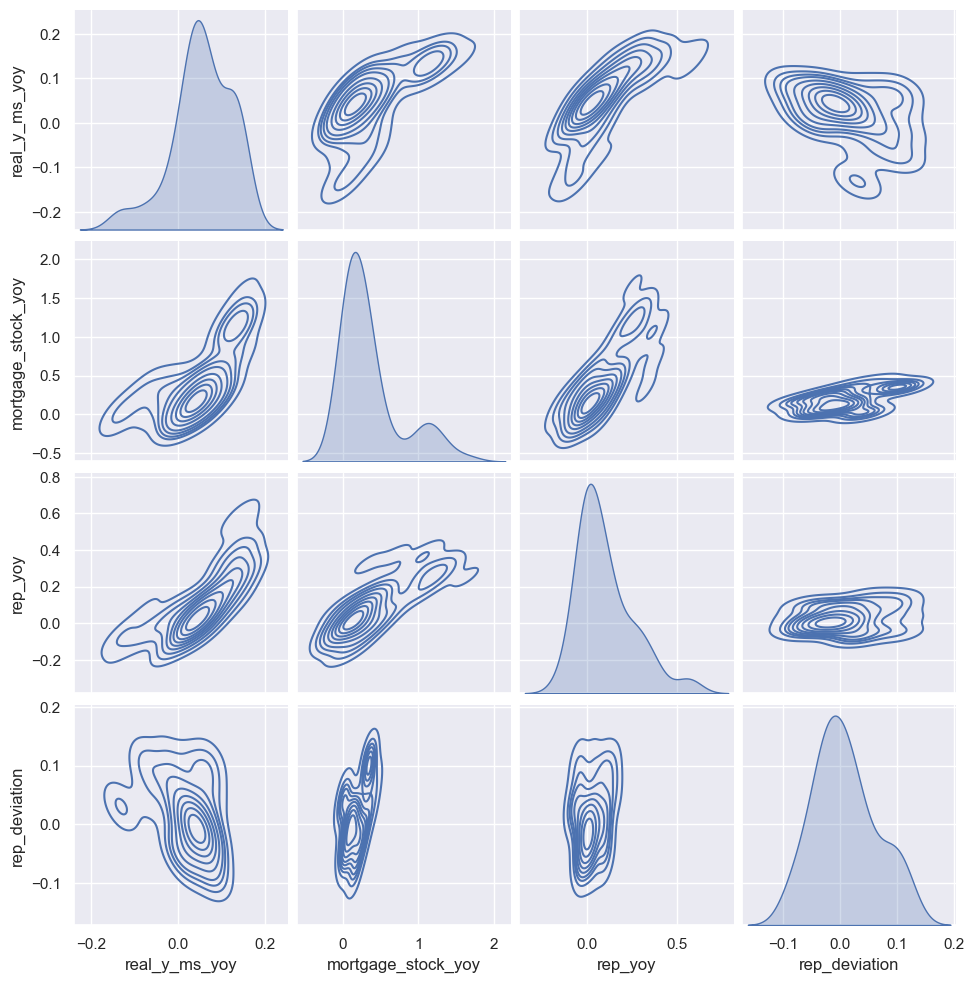

In [228]:
data_subset2 = pd.concat([data['real_y_ms_yoy'], data.iloc[:,13:16]], axis=1)
sns.pairplot(data_subset2, kind="kde")
plt.show()

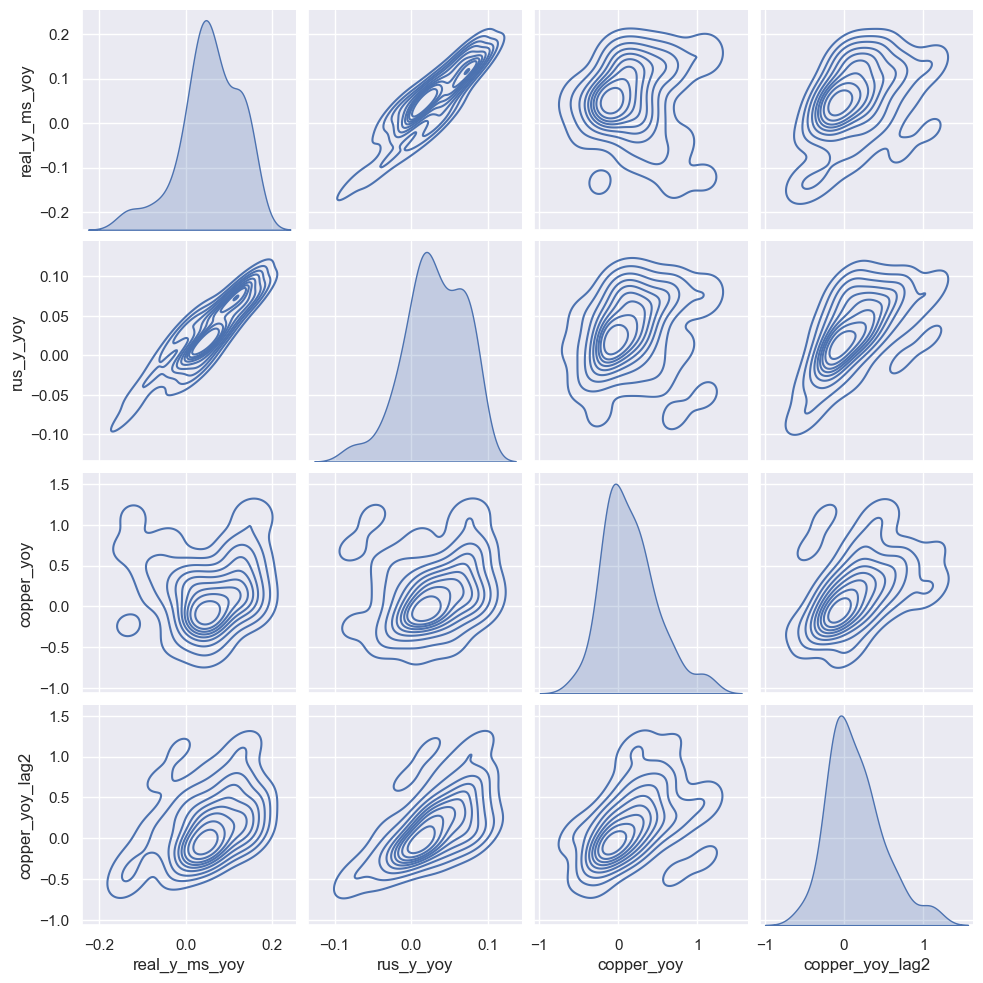

In [231]:
data_subset4 = pd.concat([data['real_y_ms_yoy'], data.iloc[:,-3:]], axis=1)
sns.pairplot(data_subset4, kind="kde")
plt.show()

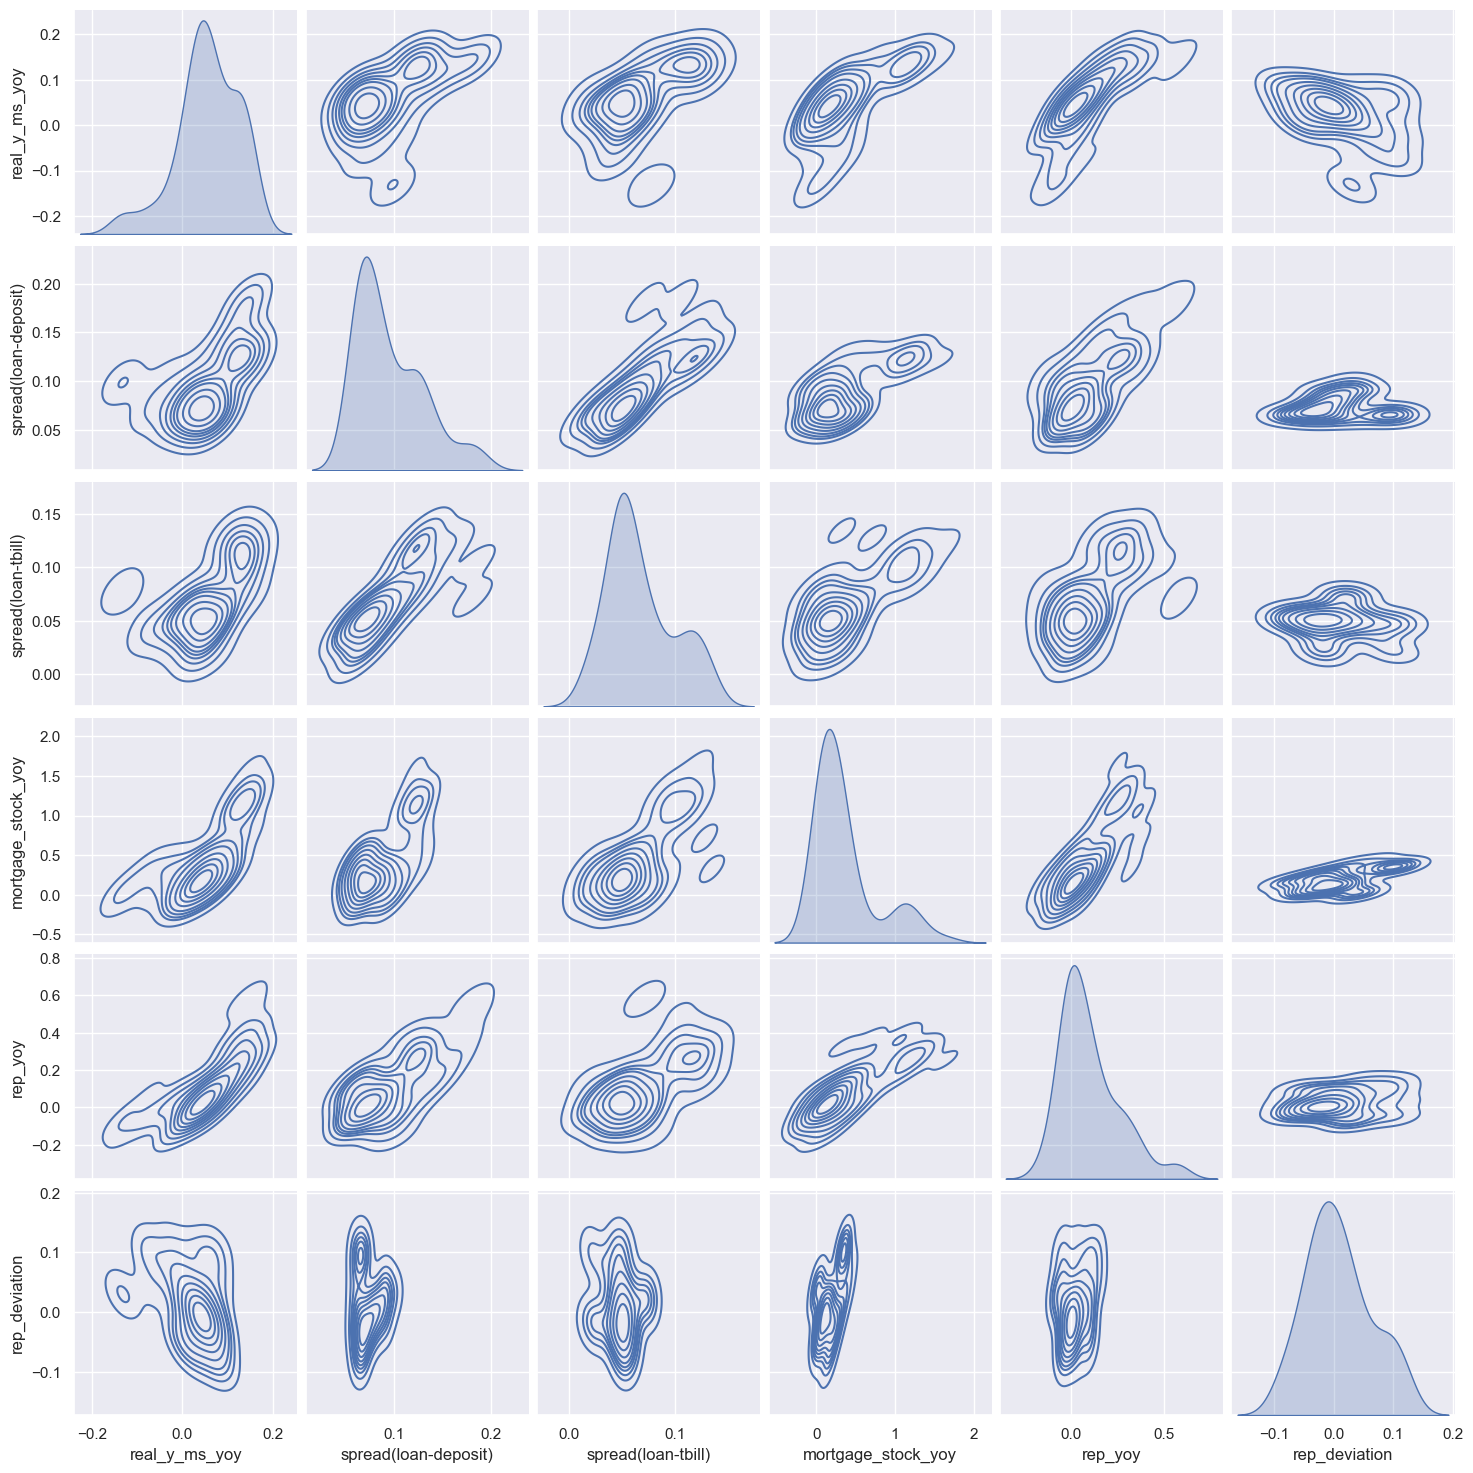

In [232]:
data_subset7 = pd.concat([data['real_y_ms_yoy'], data.iloc[:,11:16]], axis=1)
sns.pairplot(data_subset7, kind="kde")
plt.show()

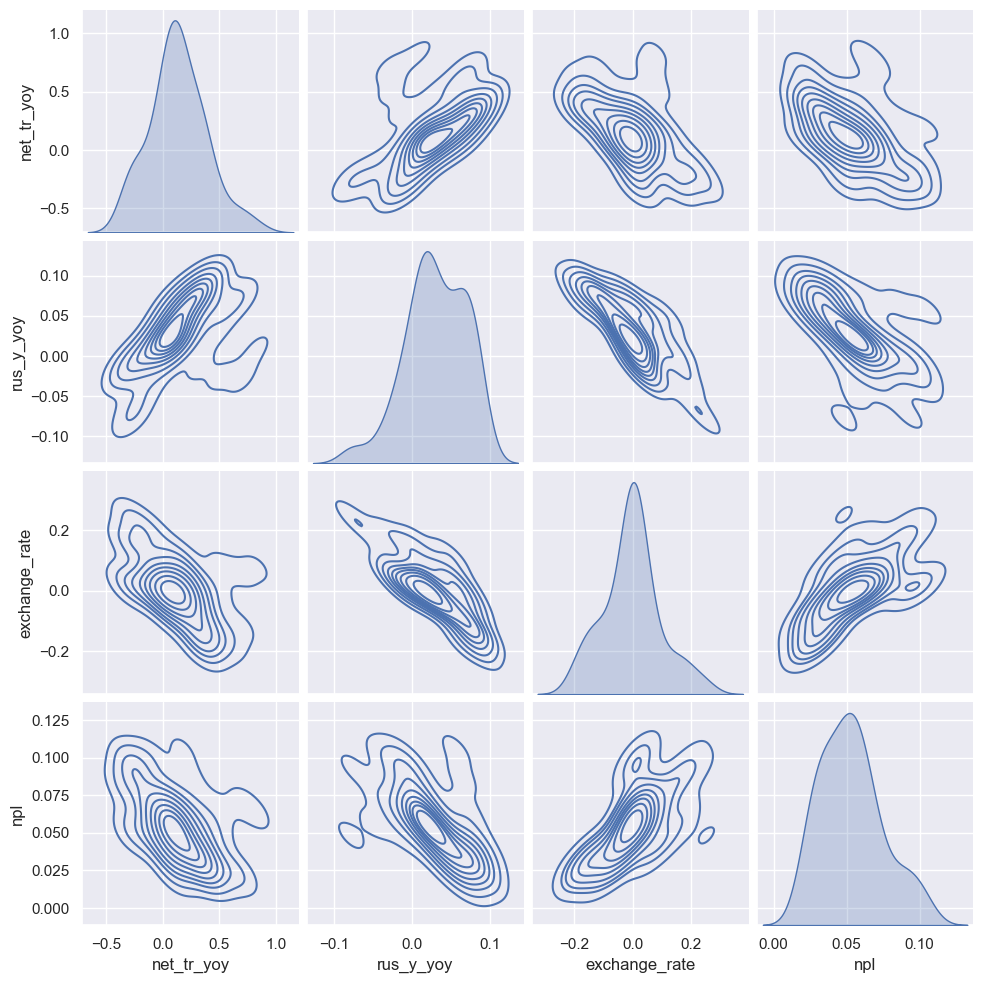

In [233]:
data_subset8 = data[["net_tr_yoy", "rus_y_yoy","exchange_rate", 'npl']]
sns.pairplot(data_subset8, kind="kde")
plt.show()

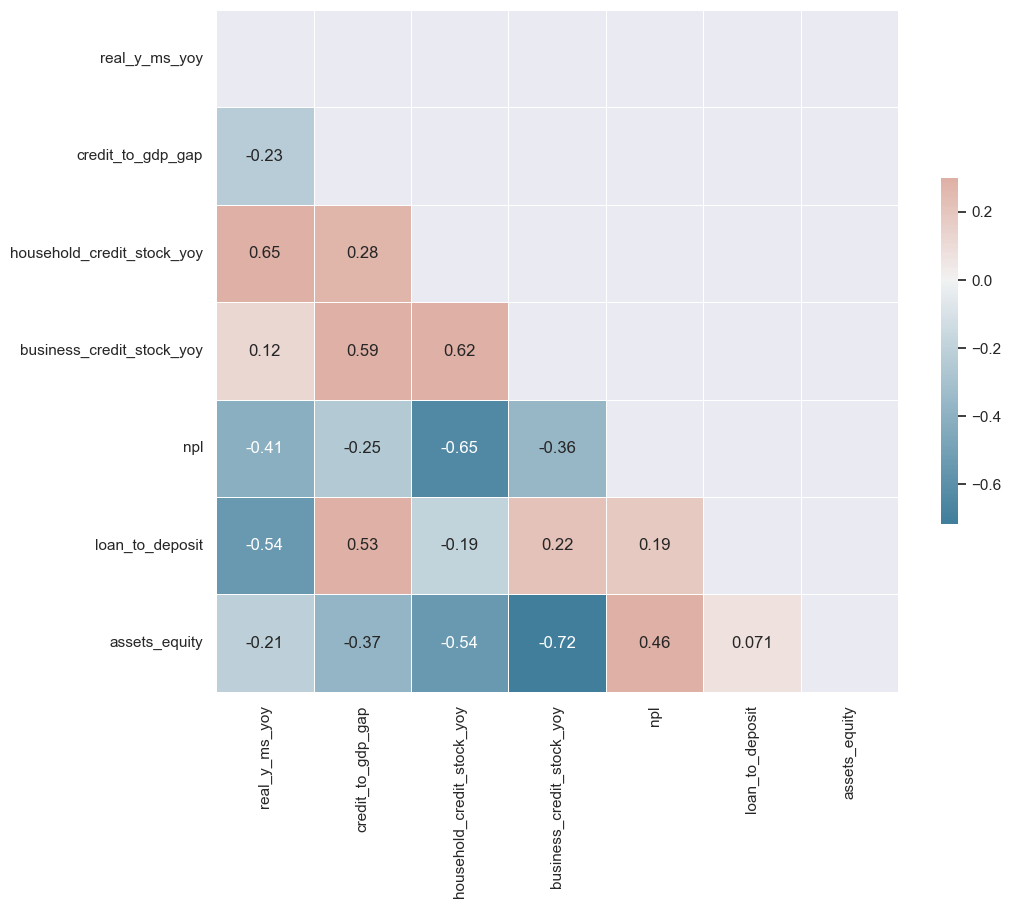

In [234]:
# Compute the correlation matrix
corr = data_subset3.corr()

# Generate a mask for the upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))

# Set up the matplotlib figure
f, ax = plt.subplots(figsize=(11, 9))

# Generate a custom diverging colormap
cmap = sns.diverging_palette(230, 20, as_cmap=True)

# Draw the heatmap with the mask and correct aspect ratio
sns.heatmap(corr, mask=mask, cmap=cmap, vmax=.3, center=0, annot=True,
            square=True, linewidths=.5, cbar_kws={"shrink": .5})
plt.show()

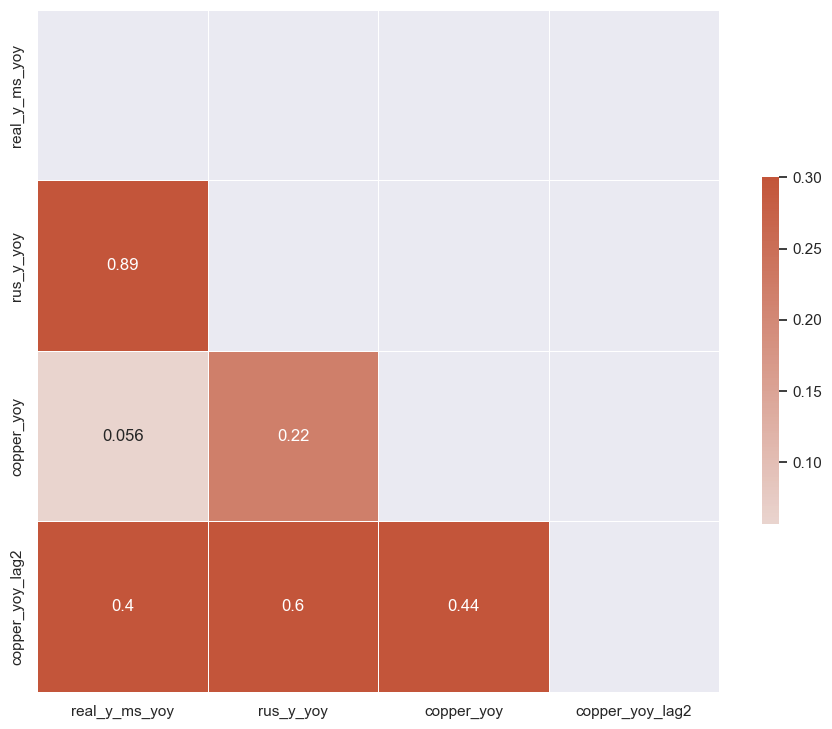

In [235]:
# Compute the correlation matrix
corr = data_subset4.corr()

# Generate a mask for the upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))

# Set up the matplotlib figure
f, ax = plt.subplots(figsize=(11, 9))

# Generate a custom diverging colormap
cmap = sns.diverging_palette(230, 20, as_cmap=True)

# Draw the heatmap with the mask and correct aspect ratio
sns.heatmap(corr, mask=mask, cmap=cmap, vmax=.3, center=0, annot=True,
            square=True, linewidths=.5, cbar_kws={"shrink": .5})
plt.show()

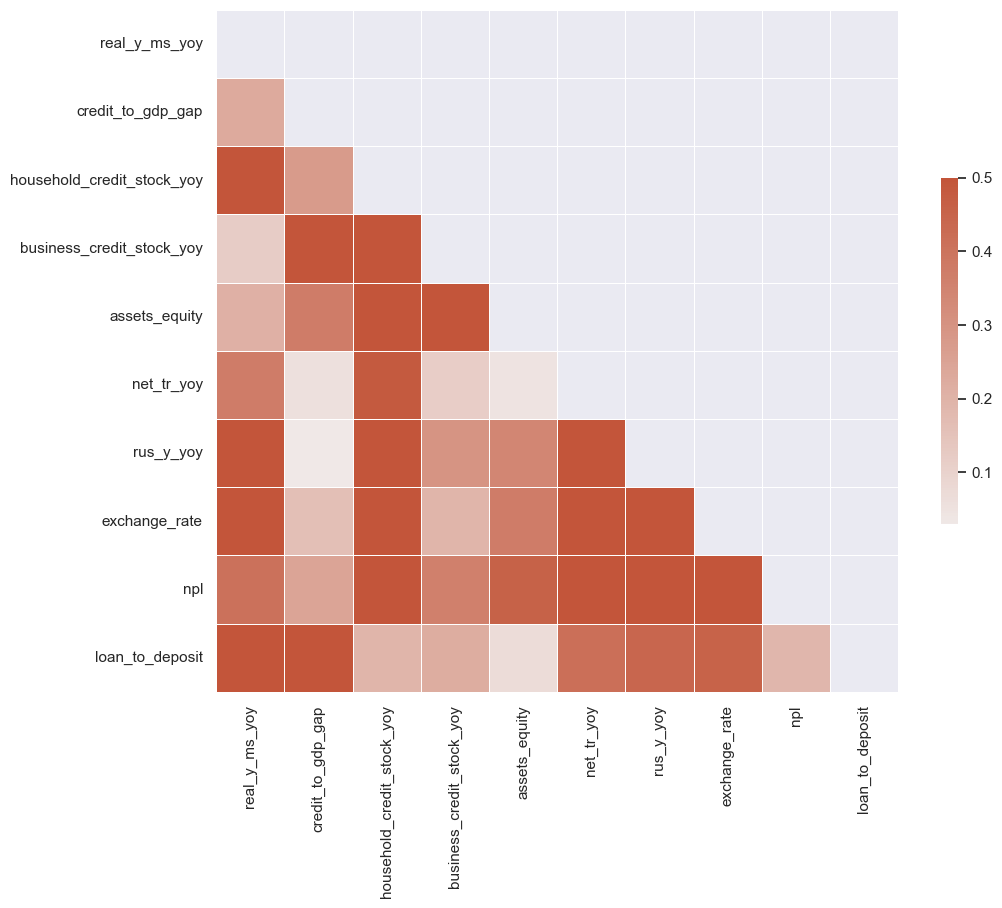

In [238]:
custom_groups = ['real_y_ms_yoy', 'credit_to_gdp_gap', "household_credit_stock_yoy",
                 "business_credit_stock_yoy", "assets_equity", "net_tr_yoy", "rus_y_yoy",
                 "exchange_rate", 'npl', 'loan_to_deposit']

# Compute the correlation matrix
corr = data[custom_groups].corr().abs()

# Generate a mask for the upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))

# Set up the matplotlib figure
f, ax = plt.subplots(figsize=(11, 9))

# Generate a custom diverging colormap
cmap = sns.diverging_palette(230, 20, as_cmap=True)

# Draw the heatmap with the mask and correct aspect ratio
sns.heatmap(corr, mask=mask, cmap=cmap, vmax=.5, center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .5})
plt.show()

*Where to take NPL*

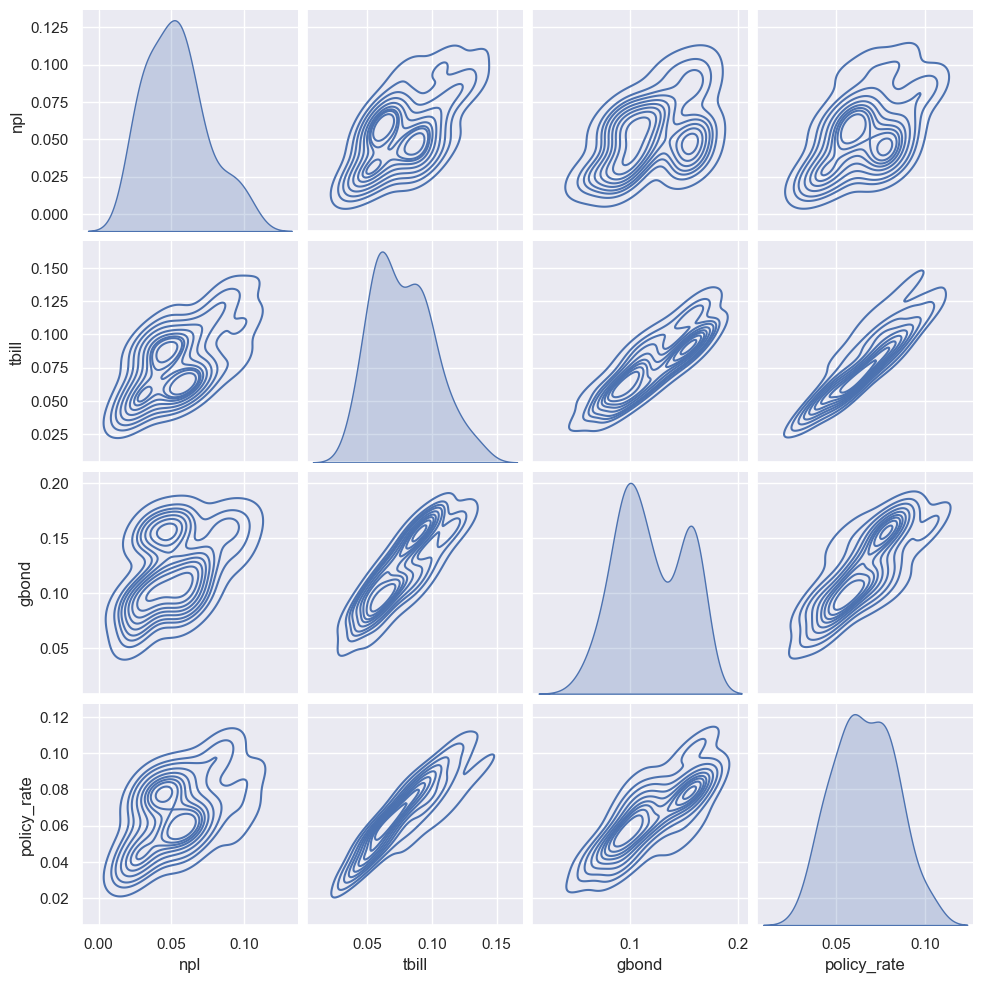

In [239]:
choice_1 = ['npl', 'tbill', 'gbond', 'policy_rate']
choice_2 = ["npl", "loan_to_deposit", 'spread(loan-deposit)', "spread(loan-tbill)"]

data_subset9 = data[choice_1]
sns.pairplot(data_subset9, kind="kde")
plt.show()

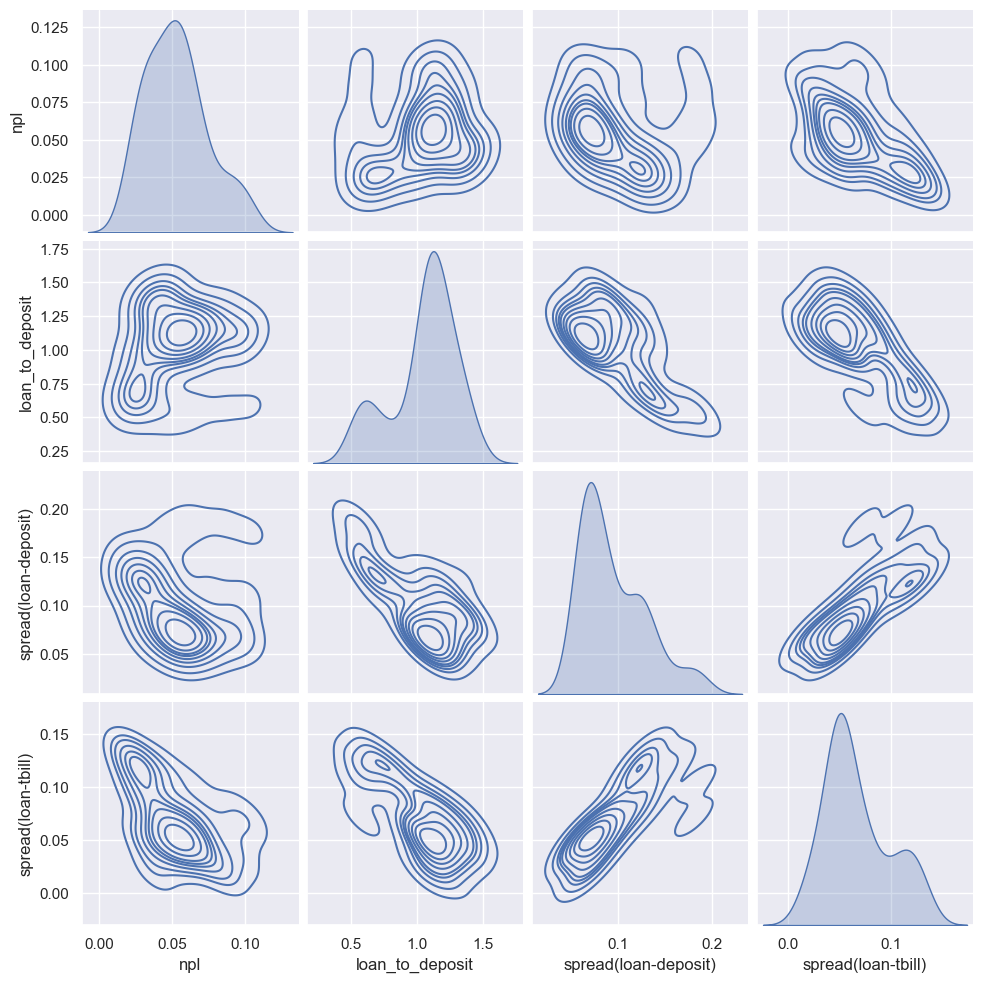

In [241]:
choice_1 = ['npl', 'tbill', 'gbond', 'policy_rate']
choice_2 = ["npl", "loan_to_deposit", 'spread(loan-deposit)', "spread(loan-tbill)"]

data_subset9 = data[choice_2]
sns.pairplot(data_subset9, kind="kde")
plt.show()

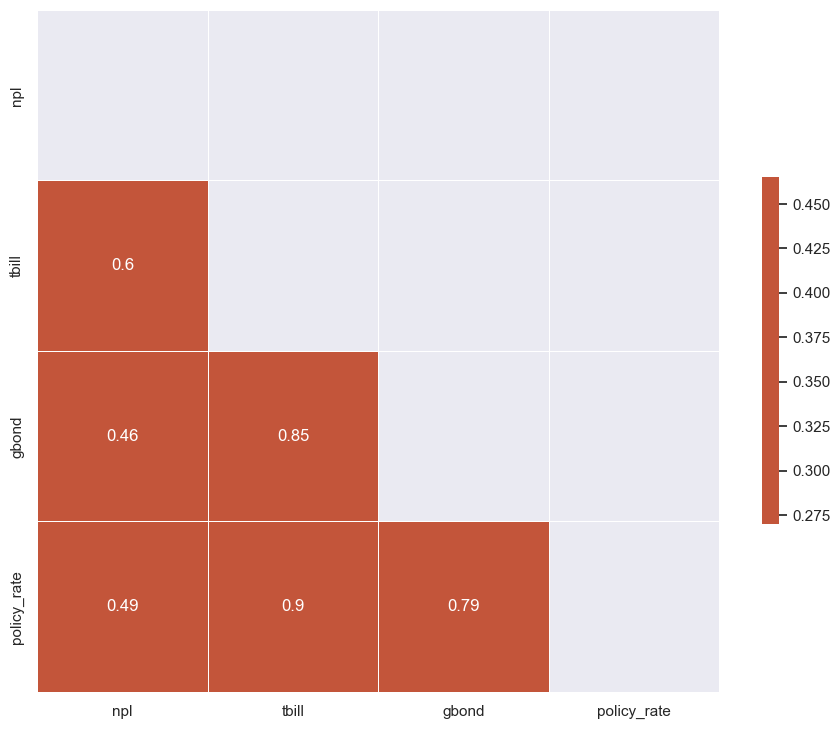

In [242]:
# Compute the correlation matrix
corr = data[choice_1].corr()

# Generate a mask for the upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))

# Set up the matplotlib figure
f, ax = plt.subplots(figsize=(11, 9))

# Generate a custom diverging colormap
cmap = sns.diverging_palette(230, 20, as_cmap=True)

# Draw the heatmap with the mask and correct aspect ratio
sns.heatmap(corr, mask=mask, cmap=cmap, vmax=.3, center=0, annot=True,
            square=True, linewidths=.5, cbar_kws={"shrink": .5})
plt.show()

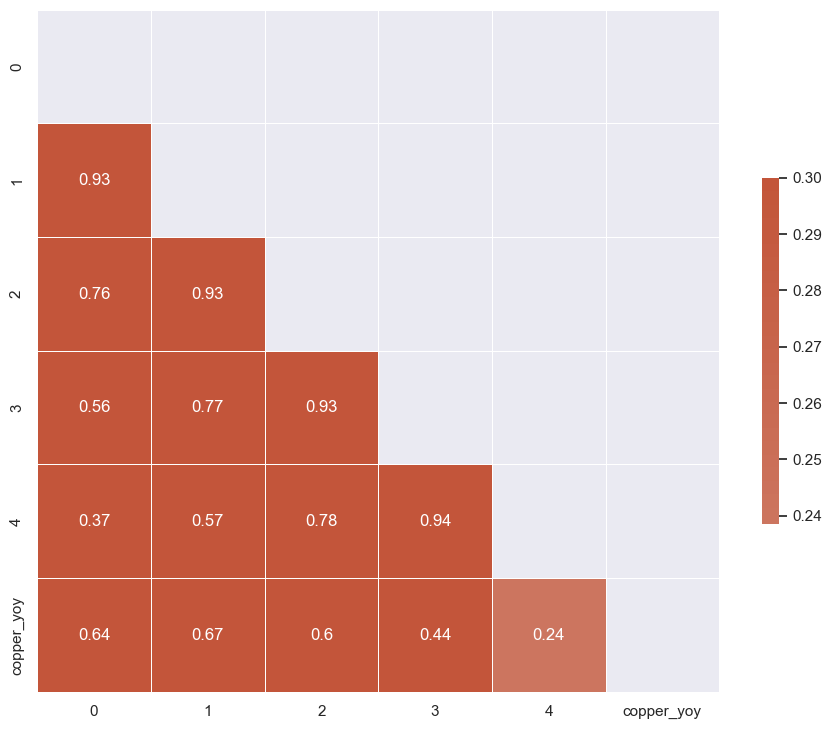

In [243]:
lags = pd.DataFrame(lagmat(data["rus_y_yoy"], maxlag=4, trim="backward", original="in"))
lags['copper_yoy'] = data['copper_yoy'].reset_index(drop=True)

corr =lags.iloc[:-4].corr()

# Generate a mask for the upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))

# Set up the matplotlib figure
f, ax = plt.subplots(figsize=(11, 9))

# Generate a custom diverging colormap
cmap = sns.diverging_palette(230, 20, as_cmap=True)

# Draw the heatmap with the mask and correct aspect ratio
sns.heatmap(corr, mask=mask, cmap=cmap, vmax=.3, center=0, annot=True,
            square=True, linewidths=.5, cbar_kws={"shrink": .5})
plt.show()

We will be choosing the 2nd lag (2), due to personal bias.

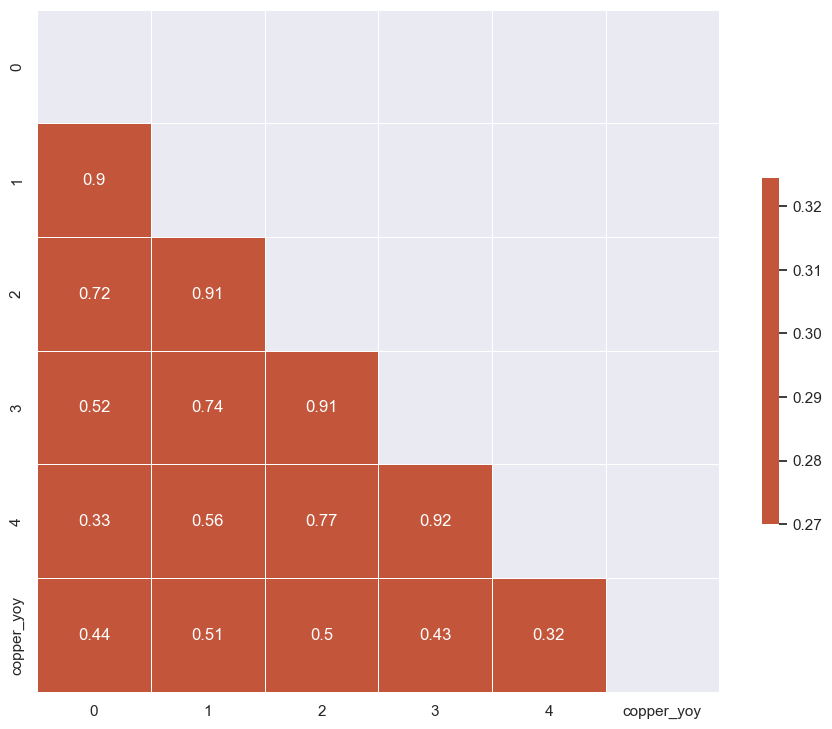

In [244]:
lags = pd.DataFrame(lagmat(data["net_tr_yoy"], maxlag=4, trim="backward", original="in"))
lags['copper_yoy'] = data['copper_yoy'].reset_index(drop=True)

corr =lags.iloc[:-4].corr()

# Generate a mask for the upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))

# Set up the matplotlib figure
f, ax = plt.subplots(figsize=(11, 9))

# Generate a custom diverging colormap
cmap = sns.diverging_palette(230, 20, as_cmap=True)

# Draw the heatmap with the mask and correct aspect ratio
sns.heatmap(corr, mask=mask, cmap=cmap, vmax=.3, center=0, annot=True,
            square=True, linewidths=.5, cbar_kws={"shrink": .5})
plt.show()

We will be choosing the 2nd lag (2), due to personal bias (again).

In [245]:
d = pd.DataFrame(data["copper_yoy"].reset_index(drop=True).iloc[:-2])
d['trend'] = np.arange(2, len(data["copper_yoy"]))
d = pd.concat([d, data[['rus_y_yoy', 'net_tr_yoy']].iloc[2:].reset_index(drop=True)], axis=1)
d

,copper_yoy,trend,rus_y_yoy,net_tr_yoy
0,0.068447,2,0.069515,0.235786
1,0.018353,3,0.073595,0.299377
2,0.156579,4,0.072799,0.374815
3,0.325099,5,0.073080,0.324320
4,0.641502,6,0.075825,0.390230
...,...,...,...,...
70,0.124436,72,-0.030575,0.703894
71,0.218186,73,0.010397,0.840539
72,0.504671,74,0.029425,0.482255
73,0.813952,75,0.047496,0.254740


In [246]:
import statsmodels.api as sm
y = d['copper_yoy']
x = sm.add_constant(d.drop(columns="copper_yoy"))

mod = sm.OLS(y, x)
res = mod.fit()
print(res.summary())

                            OLS Regression Results                            
Dep. Variable:             copper_yoy   R-squared:                       0.395
Model:                            OLS   Adj. R-squared:                  0.369
Method:                 Least Squares   F-statistic:                     15.45
Date:                Wed, 03 May 2023   Prob (F-statistic):           7.77e-08
Time:                        19:07:16   Log-Likelihood:                -7.2926
No. Observations:                  75   AIC:                             22.59
Df Residuals:                      71   BIC:                             31.86
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0470      0.092     -0.511      0.6

## Network Analysis

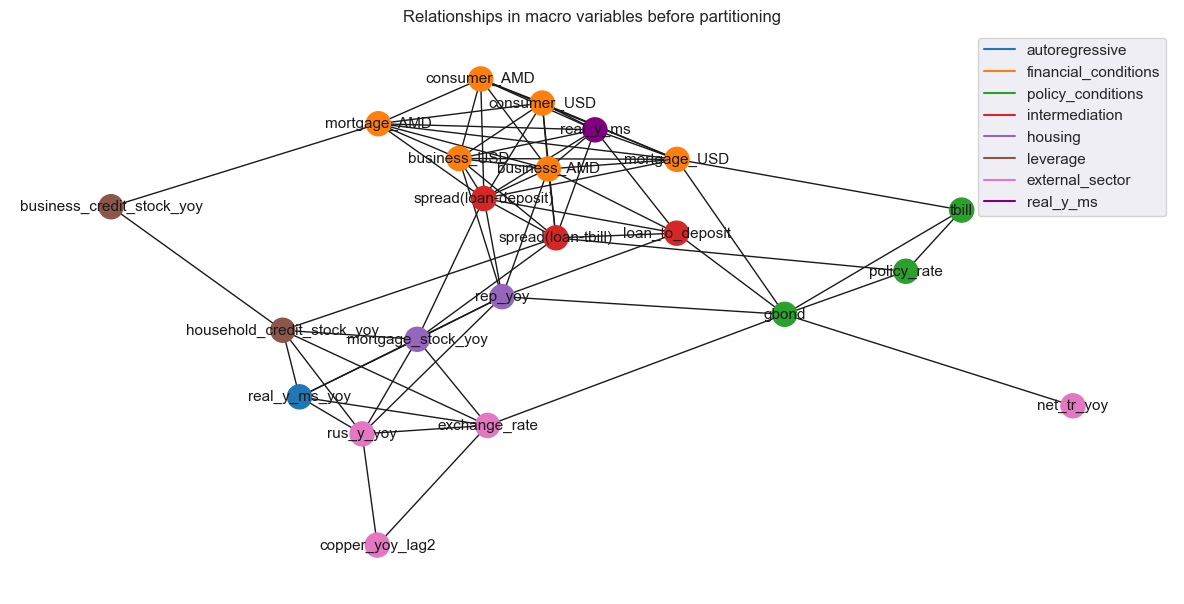

In [405]:
# Network overview
sns.set(rc={'figure.figsize': (12, 6)})
seed_id = 42
to_drop = ['rep_deviation', 'npl', 'assets_equity', 'copper_yoy', 'credit_to_gdp_gap']
corr = data.drop(columns=to_drop).corr().copy()
n = corr.shape[0]
macro_graph_adj = corr.applymap(truncate, threshold=0.6) - np.identity(n)

# variable graph 
macronet = nx.from_numpy_array(macro_graph_adj.to_numpy())
macronet = nx.relabel_nodes(macronet, dict(enumerate(macro_graph_adj.columns)))
macro_layout = nx.spring_layout(macronet, seed=seed_id, iterations=50)

f = plt.figure(1)
ax = f.add_subplot(1,1,1)
for label, color in color_mapping.items():
    ax.plot([0],[0],
            color=color,
            label=label)

# plot results
nx.draw(macronet, macro_layout, node_color=[node_colors[i] for i in macronet], font_size=11, with_labels=True)
plt.legend(loc='upper right')
f.tight_layout()
plt.title('Relationships in macro variables before partitioning')
plt.show()

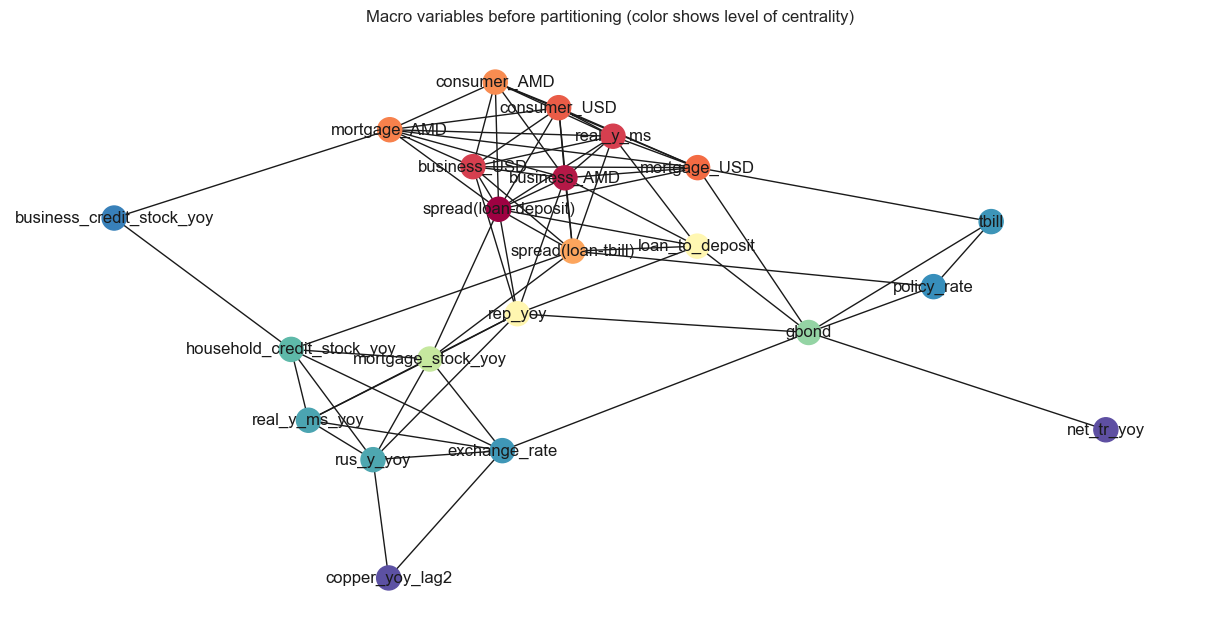

In [407]:
centrality = nx.eigenvector_centrality(macronet)
n_colors = [centrality[i] for i in macronet]
nx.draw(macronet, macro_layout, node_color=n_colors, cmap=plt.cm.Spectral_r, with_labels=True) 
plt.title('Macro variables before partitioning (color shows level of centrality)')
plt.show()

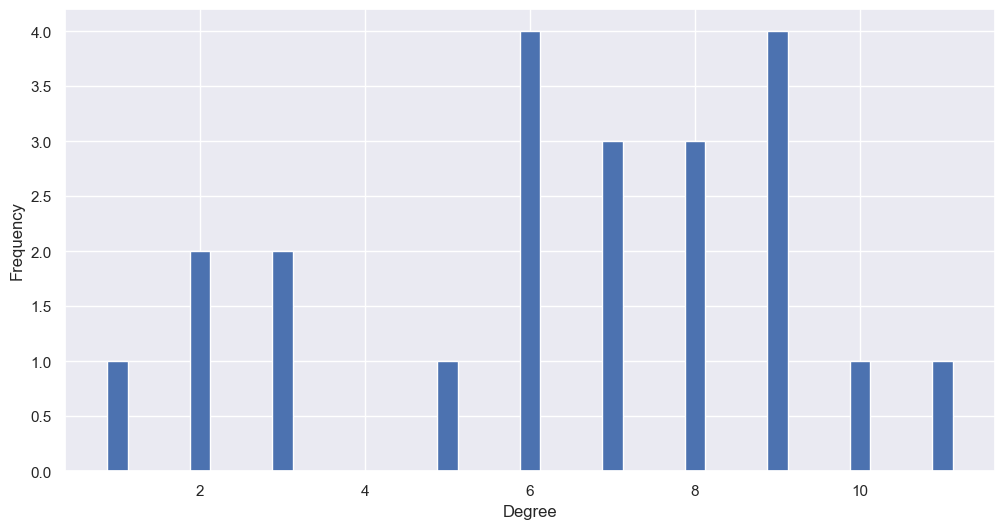

In [404]:
deg = macronet.degree()
plt.bar(*np.unique([d for n,d in deg], return_counts=True),width=0.25)
plt.xlabel("Degree")
plt.ylabel("Frequency")
plt.show()